# HSC Galaxies

> Computation of the cluster galaxy flux for a [worked example](05_hsc_analysis.ipynb) of analysing the ICL in images from the HSC-SSP deep survey.

In [ ]:
# | default_exp hsc.galaxies

In [ ]:
# | hide
from os.path import join

import astropy.cosmology.units as cu
import astropy.units as u
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pointpats
import shapely
import shapely.plotting
from astropy.constants import c
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from astropy.stats import sigma_clipped_stats
from astropy.table import QTable
from astropy.visualization import AsinhStretch, ImageNormalize
from sigfig import round

from nicl.hsc.preparation import f21_cluster_image, find_field, get_f21_table2

In [ ]:
local_data_path = "/Users/spb/data/hsc/"

## Calculating the cluster galaxy flux

First we sum the flux of all galaxies that could be members. We then calibrate a correction for the contribution of background galaxies and remove it from the initial galaxy flux estimate.

In [ ]:
cluster = get_f21_table2()[0]

In [ ]:
img, mask, sigma = f21_cluster_image(
    cluster["XCS ID"], "i", local_data_path, return_hdus=True
)

/Users/spb/data/hsc/XMMXCS_J022456.1-050802.0/XMMXCS_J022456.1-050802.0_i.fits


In [ ]:
def read_cat(field_name):
    #    return QTable.read(join(local_data_path, f'{field_name}_cat.csv'), format='ascii.commented_header')
    return QTable.read(join(local_data_path, f"{field_name}_cat.fits"), memmap=True)

In [ ]:
def add_instrumental_fluxes(cat, zp):
    for band in "grizy":
        instmag = cat[f"{band}_kronflux_mag"] - zp.to_value(u.ABmag)
        cat[f"{band}_instflux"] = 10 ** (-instmag / 2.5)

In [ ]:
def add_offsets(cat):
    origin = SkyCoord(cat["coord"].ra.mean(), cat["coord"].dec.mean())
    cat["offsets"] = cat["coord"].transform_to(SkyOffsetFrame(origin=origin))

In [ ]:
def get_zmatch_cat(z_cluster, ra_cluster, dec_cluster, zp, only_matches=True):
    coord_cluster = SkyCoord(ra_cluster, dec_cluster)
    field_name = find_field(coord_cluster)
    cat = read_cat(field_name)
    cat = cat[cat["photoz_best"] > 0.01]
    cat = cat[cat["photoz_best"] < 1.6]
    cat = cat[~cat["i_mask_brightstar_halo"]]
    delta_z_photoz = 3 * 0.05 * (1 + cat["photoz_best"])
    delta_v_cl = 3000 * (u.km / u.s)
    delta_z_cl = ((delta_v_cl / c) * (1 + z_cluster)).to(cu.redshift)
    cat["phot_z_match"] = np.abs(cat["photoz_best"] - z_cluster) < delta_z_photoz
    cat["spec_z_match"] = ~cat["specz_redshift_isnull"] & (
        np.abs(cat["specz_redshift"] - z_cluster) < delta_z_cl
    )
    cat["spec_z_excluded"] = ~cat["specz_redshift_isnull"] & ~cat["spec_z_match"]
    if only_matches:
        z_match = cat["spec_z_match"] | cat["phot_z_match"]
        cat = cat[z_match]
    cat["coord"] = SkyCoord(cat["ra"], cat["dec"], unit="deg")
    add_instrumental_fluxes(cat, zp=zp)
    add_offsets(cat)
    return cat

In [ ]:
def in_aperture(cat_coord, ra, dec, radius):
    coord_aperture = SkyCoord(ra, dec)
    separations = coord_aperture.separation(cat_coord).to(u.arcsec)
    return separations < radius

In [ ]:
cat = get_zmatch_cat(cluster["z"], cluster["ra"], cluster["dec"], zp=27 * u.ABmag)

In [ ]:
bcg_centred = True
in_cluster = in_aperture(
    cat["coord"], cluster["ra"], cluster["dec"], cluster["R_X_arcsec"]
)
if not bcg_centred:
    # attempt to recentre on the BCG; this is rather simplistic
    spec_members = cat[in_cluster & cat["spec_z_match"]]
    bcg_idx = np.argmax(spec_members["i_instflux"])
    bcg = spec_members[bcg_idx]
    in_cluster = in_aperture(
        cat, bcg["coord"].ra, bcg["coord"].dec, cluster["R_X_arcsec"]
    )

In [ ]:
candidates_all = cat[in_cluster]
members_all = candidates_all[
    (candidates_all["spec_z_match"] | candidates_all["phot_z_match"])
    & ~candidates_all["spec_z_excluded"]
]
members_spec_z = members_all[members_all["spec_z_match"]]

<matplotlib.collections.PathCollection>

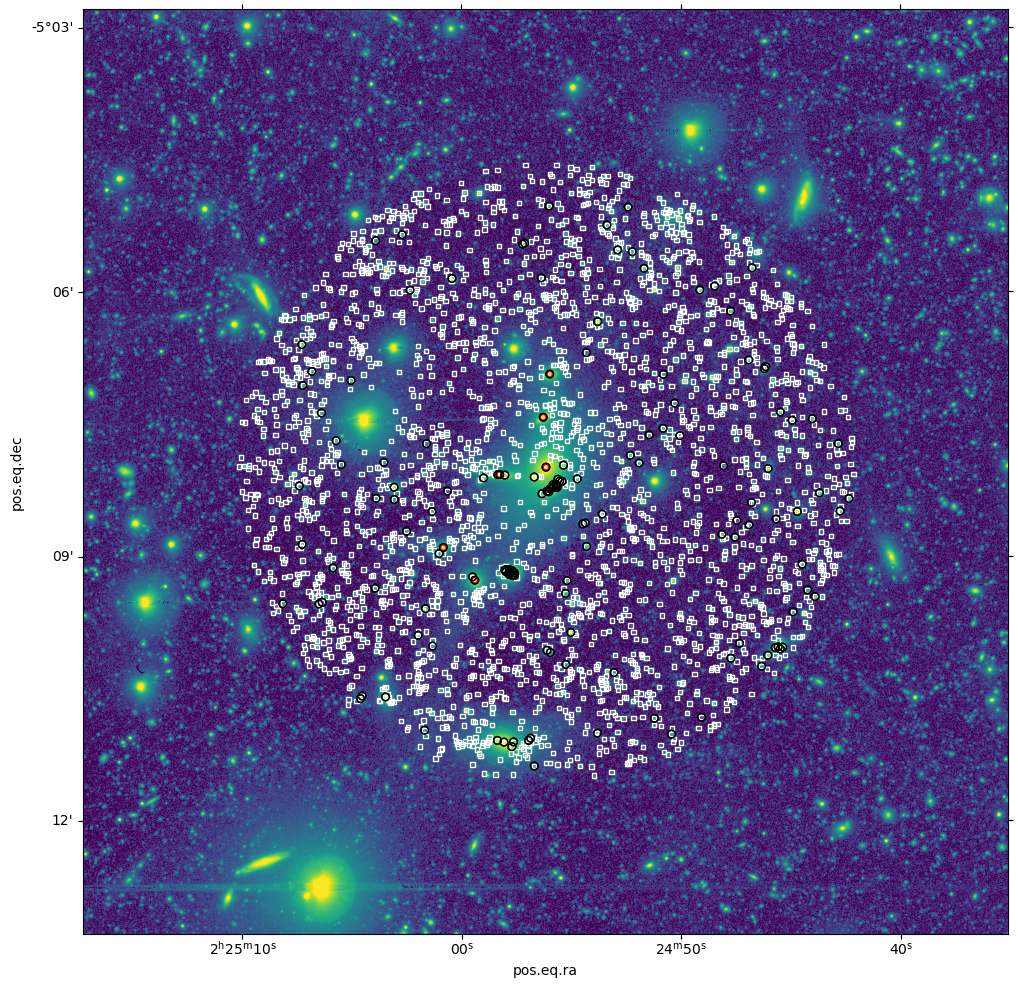

In [ ]:
norm = ImageNormalize(vmin=-0.01, vmax=10, stretch=AsinhStretch(0.001))
fig = plt.figure(figsize=(12, 12))
ax = plt.subplot(projection=img.wcs)
ax.imshow(img, norm=norm, origin="lower")
ax.scatter(
    candidates_all["ra"],
    candidates_all["dec"],
    marker="s",
    c="none",
    edgecolors="w",
    s=10,
    transform=ax.get_transform("world"),
)
ax.scatter(
    members_all["ra"],
    members_all["dec"],
    marker="o",
    c="none",
    edgecolors="k",
    s=30,
    transform=ax.get_transform("world"),
)
ax.scatter(
    members_spec_z["ra"],
    members_spec_z["dec"],
    marker="o",
    c="none",
    edgecolors="r",
    s=15,
    transform=ax.get_transform("world"),
)
ax.scatter(
    members_all["ra"],
    members_all["dec"],
    marker="o",
    c="none",
    edgecolors="k",
    s=30,
    transform=ax.get_transform("world"),
)

In [ ]:
print(
    f"In the cluster aperture there are "
    f"{((candidates_all['spec_z_match'] | candidates_all['phot_z_match']) & ~candidates_all['spec_z_excluded']).sum()} membership candidates. "
    f"Of these, {candidates_all['spec_z_match'].sum()} meet the spec-z criteria and "
    f"{candidates_all['phot_z_match'].sum()} meet the photo-z criteria. "
    f"{(candidates_all['spec_z_match'] & ~candidates_all['phot_z_match']).sum()} meet only the spec-z criteria, "
    f"{(~candidates_all['spec_z_match'] & candidates_all['phot_z_match']).sum()} meet only the photo-z criteria, and "
    f"{(candidates_all['spec_z_match'] & candidates_all['phot_z_match']).sum()} meet both criteria. "
    f"{(candidates_all['phot_z_match'] & candidates_all['spec_z_excluded']).sum()} of the photo-z matches have been excluded by a spec-z."
)

In the cluster aperture there are 144 membership candidates. Of these, 8 meet the spec-z criteria and 149 meet the photo-z criteria. 0 meet only the spec-z criteria, 141 meet only the photo-z criteria, and 8 meet both criteria. 5 of the photo-z matches have been excluded by a spec-z.


In [ ]:
n_members_all = len(members_all)
n_members_spec_z = len(members_spec_z)
n_members_phot_z = n_members_all - n_members_spec_z
n_members_all, n_members_spec_z

(149, 8)

In [ ]:
flux_members_all = np.nansum(members_all["i_instflux"])
flux_members_spec_z = np.nansum(members_spec_z["i_instflux"])
flux_members_phot_z = flux_members_all - flux_members_spec_z
flux_members_all, flux_members_spec_z, flux_members_phot_z

(185057.05, 94451.86, 90605.19)

### Determine the background correction

In [ ]:
origin = SkyCoord(cat["coord"].ra.mean(), cat["coord"].dec.mean())
offsets = cat["coord"].transform_to(SkyOffsetFrame(origin=origin))[::10]

In [ ]:
n_apertures = 10000
radius = cluster["R_X_arcsec"]

In [ ]:
points = np.transpose([offsets.lon, offsets.lat])
survey_poly = shapely.concave_hull(shapely.MultiPoint(points), ratio=0.05)
buffered_survey_poly = survey_poly.buffer(-radius.to_value(u.deg))

In [ ]:
offset_cluster = SkyCoord(cluster["ra"], cluster["dec"]).transform_to(
    SkyOffsetFrame(origin=origin)
)
cluster_poly = shapely.Point(
    offset_cluster.lon.to_value(u.deg), offset_cluster.lat.to_value(u.deg)
).buffer(2 * radius.to_value(u.deg))
sample_poly = buffered_survey_poly - cluster_poly

In [ ]:
sampled_centres = pointpats.random.poisson(sample_poly, size=n_apertures)
sampled_apertures = [
    shapely.Point(c).buffer(radius.to_value(u.deg)) for c in sampled_centres
]

In [ ]:
coord_apertures = SkyCoord(
    *(sampled_centres.T * u.deg), frame=cat["offsets"].frame
).transform_to("icrs")

In [ ]:
count = []
flux = []
cat_phot = cat[cat["phot_z_match"]]
for coord in coord_apertures:
    in_bkg_ap = in_aperture(cat_phot["coord"], coord.ra, coord.dec, radius)
    bkg = cat_phot[in_bkg_ap]
    count.append(len(bkg))
    flux.append(np.nansum(bkg["i_instflux"]))

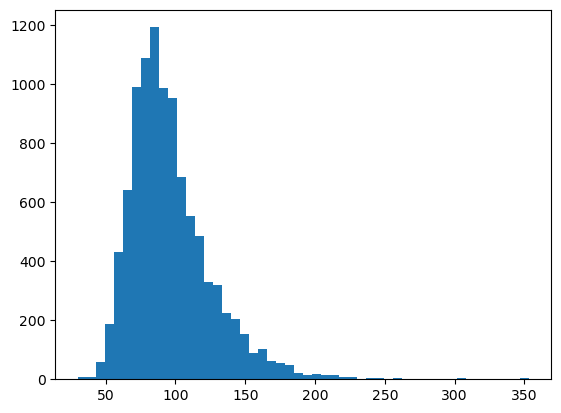

In [ ]:
plt.hist(count, bins=50);

In [ ]:
bkg_mean_count, bkg_median_count, bkg_std_count = sigma_clipped_stats(count, sigma=3)
bkg_mean_count, bkg_median_count, bkg_std_count

(93.16218740271869, 90.0, 23.832375046388336)

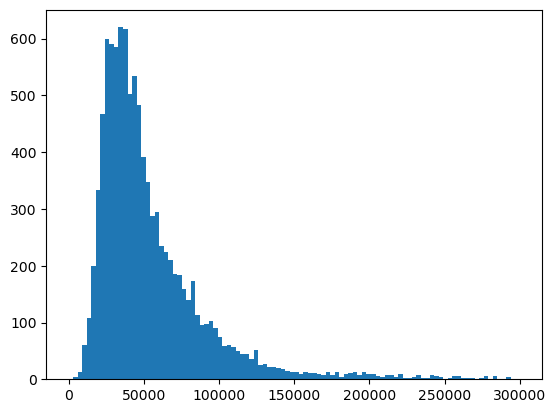

In [ ]:
plt.hist(flux, bins=100, range=(0, 3e5));

In [ ]:
bkg_mean_flux, bkg_median_flux, bkg_std_flux = sigma_clipped_stats(flux, sigma=3)
bkg_mean_flux, bkg_median_flux, bkg_std_flux

(46591.63671875, 41674.63671875, 22154.521484375)

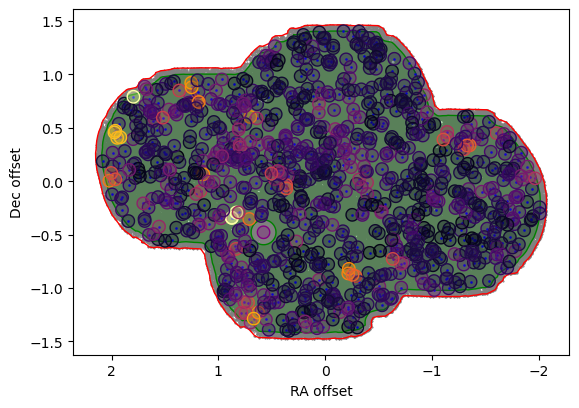

In [ ]:
fig, ax = plt.subplots()
ax.set_aspect(1)
ax.scatter(points[:, 0], points[:, 1], marker=".", c="grey", s=1)
shapely.plotting.plot_polygon(
    survey_poly, add_points=False, facecolor="none", edgecolor="r", ax=ax
)
buffered_survey_poly = survey_poly.buffer(-radius.to_value("deg"))
shapely.plotting.plot_polygon(sample_poly, add_points=False, color="g", ax=ax)
shapely.plotting.plot_polygon(
    cluster_poly.buffer(-radius.to_value(u.deg)),
    add_points=False,
    color="purple",
    ax=ax,
)
ax.scatter(sampled_centres[::10, 0], sampled_centres[::10, 1], marker=".", c="b", s=3)
cmap = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=0, vmax=3e5), cmap="inferno"
)
for i, ap in enumerate(sampled_apertures):
    if i % 10 == 0:
        shapely.plotting.plot_polygon(
            ap, add_points=False, color=cmap.to_rgba(flux[i]), ax=ax
        )
ax.set_xlabel("RA offset")
ax.set_ylabel("Dec offset")
ax.invert_xaxis()

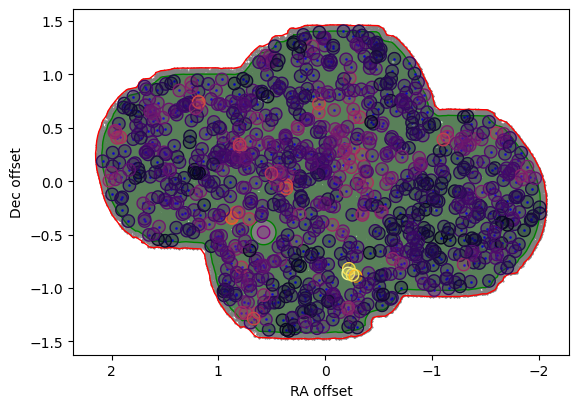

In [ ]:
import shapely.plotting

fig, ax = plt.subplots()
ax.set_aspect(1)
ax.scatter(points[:, 0], points[:, 1], marker=".", c="grey", s=1)
shapely.plotting.plot_polygon(
    survey_poly, add_points=False, facecolor="none", edgecolor="r", ax=ax
)
buffered_survey_poly = survey_poly.buffer(-radius.to_value("deg"))
shapely.plotting.plot_polygon(sample_poly, add_points=False, color="g", ax=ax)
shapely.plotting.plot_polygon(
    cluster_poly.buffer(-radius.to_value(u.deg)),
    add_points=False,
    color="purple",
    ax=ax,
)
ax.scatter(sampled_centres[::10, 0], sampled_centres[::10, 1], marker=".", c="b", s=3)
cmap = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=np.min(count), vmax=np.max(count)), cmap="inferno"
)
for i, ap in enumerate(sampled_apertures):
    if i % 10 == 0:
        shapely.plotting.plot_polygon(
            ap, add_points=False, color=cmap.to_rgba(count[i]), ax=ax
        )
ax.set_xlabel("RA offset")
ax.set_ylabel("Dec offset")
ax.invert_xaxis()

In [ ]:
members_phot_z_frac = n_members_phot_z / n_members_all

In [ ]:
flux_members_all_flux_corr = flux_members_all - bkg_mean_flux * members_phot_z_frac
flux_members_all_flux_corr_err = bkg_std_flux * members_phot_z_frac

In [ ]:
flux_members_all_count_corr = (
    flux_members_all
    - bkg_mean_count * members_phot_z_frac * flux_members_phot_z / n_members_phot_z
)
flux_members_all_count_corr_err = (
    bkg_std_count * members_phot_z_frac * flux_members_phot_z / n_members_phot_z
)

In [ ]:
flux_members_all_corr = 0.5 * (flux_members_all_flux_corr + flux_members_all_count_corr)
flux_members_all_corr_err = 0.5 * np.sqrt(
    flux_members_all_flux_corr_err**2 + flux_members_all_count_corr_err**2
)

In [ ]:
print(f"Uncorrected member galaxy flux is {flux_members_all:.0f}.")
print(
    f"Count-corrected member galaxy flux is {round(flux_members_all_count_corr, flux_members_all_count_corr_err)}."
)
print(
    f"Flux-corrected member galaxy flux is {round(flux_members_all_flux_corr, flux_members_all_flux_corr_err)}."
)
print(
    f"Final corrected member galaxy flux is {round(flux_members_all_corr, flux_members_all_corr_err)}."
)

Uncorrected member galaxy flux is 185057.
Count-corrected member galaxy flux is 130000 ± 10000.
Flux-corrected member galaxy flux is 140000 ± 20000.
Final corrected member galaxy flux is 130000 ± 10000.
